In [ ]:
method='LINGER'

import pandas as pd
barcodes = pd.read_csv('./barcodes.tsv', sep='\t', header=None)


In [ ]:
import scanpy as sc
%matplotlib inline
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(5, 5), facecolor='white')
sc.settings.verbosity = 3
sc.logging.print_header()

import scipy
import pandas as pd
import re

# 读取数据
matrix = scipy.io.mmread('./matrix.mtx')
features = pd.read_csv('./features.tsv', sep='\t', header=None)


labels_df = pd.DataFrame({'barcode_use': barcodes[0], 'label': labels.values})
from LingerGRN.preprocess import get_adata
adata_RNA, adata_ATAC = get_adata(matrix, features, barcodes, labels_df)

scanpy==1.9.5 anndata==0.9.2 umap==0.5.7 numpy==1.24.3 scipy==1.11.3 pandas==2.0.3 scikit-learn==1.3.0 statsmodels==0.14.1 pynndescent==0.5.13


In [45]:
import scanpy as sc
sc.pp.filter_cells(adata_RNA, min_genes=200)
print(adata_RNA.shape)
sc.pp.filter_genes(adata_RNA, min_cells=3)
print(adata_RNA.shape)
sc.pp.filter_cells(adata_ATAC, min_genes=200)
print(adata_ATAC.shape)
sc.pp.filter_genes(adata_ATAC, min_cells=3)
print(adata_ATAC.shape)

selected_barcode=list(set(adata_RNA.obs['barcode'].values)&set(adata_ATAC.obs['barcode'].values))
barcode_idx=pd.DataFrame(range(adata_RNA.shape[0]), index=adata_RNA.obs['barcode'].values)
adata_RNA = adata_RNA[barcode_idx.loc[selected_barcode][0]]
barcode_idx=pd.DataFrame(range(adata_ATAC.shape[0]), index=adata_ATAC.obs['barcode'].values)
adata_ATAC = adata_ATAC[barcode_idx.loc[selected_barcode][0]]

filtered out 834 cells that have less than 200 genes expressed
(9871, 36601)


/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


filtered out 5600 genes that are detected in less than 3 cells
(9871, 31001)
filtered out 256 cells that have less than 200 genes expressed


/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


(10449, 111588)
(10449, 111588)


In [47]:
from LingerGRN.pseudo_bulk import *
samplelist=list(set(adata_ATAC.obs['sample'].values)) # sample is generated from cell barcode 
tempsample=samplelist[0]
TG_pseudobulk=pd.DataFrame([])
RE_pseudobulk=pd.DataFrame([])
singlepseudobulk = (adata_RNA.obs['sample'].unique().shape[0]*adata_RNA.obs['sample'].unique().shape[0]>100)
for tempsample in samplelist:
    adata_RNAtemp=adata_RNA[adata_RNA.obs['sample']==tempsample]
    adata_ATACtemp=adata_ATAC[adata_ATAC.obs['sample']==tempsample]
    TG_pseudobulk_temp,RE_pseudobulk_temp=pseudo_bulk(adata_RNAtemp,adata_ATACtemp,singlepseudobulk)                
    TG_pseudobulk=pd.concat([TG_pseudobulk, TG_pseudobulk_temp], axis=1)
    RE_pseudobulk=pd.concat([RE_pseudobulk, RE_pseudobulk_temp], axis=1)
    RE_pseudobulk[RE_pseudobulk > 100] = 100

import os
if not os.path.exists('data/'):
    os.mkdir('data/')
adata_ATAC.write('data/adata_ATAC.h5ad')
adata_RNA.write('data/adata_RNA.h5ad')
TG_pseudobulk=TG_pseudobulk.fillna(0)
RE_pseudobulk=RE_pseudobulk.fillna(0)
pd.DataFrame(adata_ATAC.var['gene_ids']).to_csv('data/Peaks.txt',header=None,index=None)
TG_pseudobulk.to_csv('data/TG_pseudobulk.tsv')
RE_pseudobulk.to_csv('data/RE_pseudobulk.tsv')

normalizing counts per cell
    finished (0:00:00)


/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


filtered out 52 genes that are detected in less than 3 cells
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:842: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


computing PCA
    on highly variable genes
    with n_comps=15
    finished (0:00:05)


/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:372: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:842: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


computing PCA
    on highly variable genes
    with n_comps=15
    finished (0:00:16)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:15)


/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


In [48]:
from LingerGRN.preprocess import *
Datadir='/home/qyyuan/data/TF_TG_software/code/'# This directory should be the same as Datadir defined in the above 'Download the general gene regulatory network' section
GRNdir=Datadir+'data_bulk/'
genome='hg38'
outdir='/home/qyyuan/project/Nature-Protocol/cancer/result/' #output dir
preprocess(TG_pseudobulk,RE_pseudobulk,GRNdir,genome,method,outdir)

Overlapping regions...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    4.2s
[Parallel(n_jobs=8)]: Done  11 out of  23 | elapsed:    5.3s remaining:    5.8s
[Parallel(n_jobs=8)]: Done  14 out of  23 | elapsed:    5.4s remaining:    3.5s
[Parallel(n_jobs=8)]: Done  17 out of  23 | elapsed:    5.8s remaining:    2.1s
[Parallel(n_jobs=8)]: Done  20 out of  23 | elapsed:    6.1s remaining:    0.9s
[Parallel(n_jobs=8)]: Done  23 out of  23 | elapsed:    7.5s finished


Mapping gene expression...
Generate TF expression...
Generate RE chromatin accessibility...
Generate TF binding...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:   18.4s
/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/joblib/ext

Generate Index...


100%|██████████| 16444/16444 [01:44<00:00, 157.89it/s]


In [51]:
import os
os.environ['LD_LIBRARY_PATH'] = '/home/qyyuan/.conda/envs/LINGER-Perellel/lib'
# 如果你想保留原有的值（如果有的话），可以用：
# original = os.environ.get('LD_LIBRARY_PATH', '')
# os.environ['LD_LIBRARY_PATH'] = f'/home/qyyuan/.conda/envs/LINGER-Perellel/lib:{original}' if original else '/home/qyyuan/.conda/envs/LINGER-Perellel/lib'



In [52]:
import LingerGRN.LINGER_tr as LINGER_tr
activef='ReLU' # active function chose from 'ReLU','sigmoid','tanh'
LINGER_tr.training(GRNdir,method,outdir,activef,'Human')

With 128 CPUs, 1007.71 GB RAM (avail. : 991.56 GB), start 23 workers


[Parallel(n_jobs=23)]: Using backend LokyBackend with 23 concurrent workers.
chr1: 100%|██████████| 1682/1682 [49:00<00:00,  1.75s/it]
[Parallel(n_jobs=23)]: Done  23 out of  23 | elapsed: 49.4min finished


In [ ]:
import LingerGRN.LL_net as LL_net
LL_net.TF_RE_binding(GRNdir,adata_RNA,adata_ATAC,genome,method,outdir)
LL_net.cis_reg(GRNdir,adata_RNA,adata_ATAC,genome,method,outdir)
LL_net.trans_reg(GRNdir,method,outdir,genome)
celltype='CD56 (bright) NK cells' #use a string to assign your cell type
celltype='all'
LL_net.cell_type_specific_TF_RE_binding(GRNdir,adata_RNA,adata_ATAC,genome,celltype,outdir,method)# different from the previous version


100%|██████████| 23/23 [01:44<00:00,  4.53s/it]
Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


<Figure size 640x480 with 0 Axes>

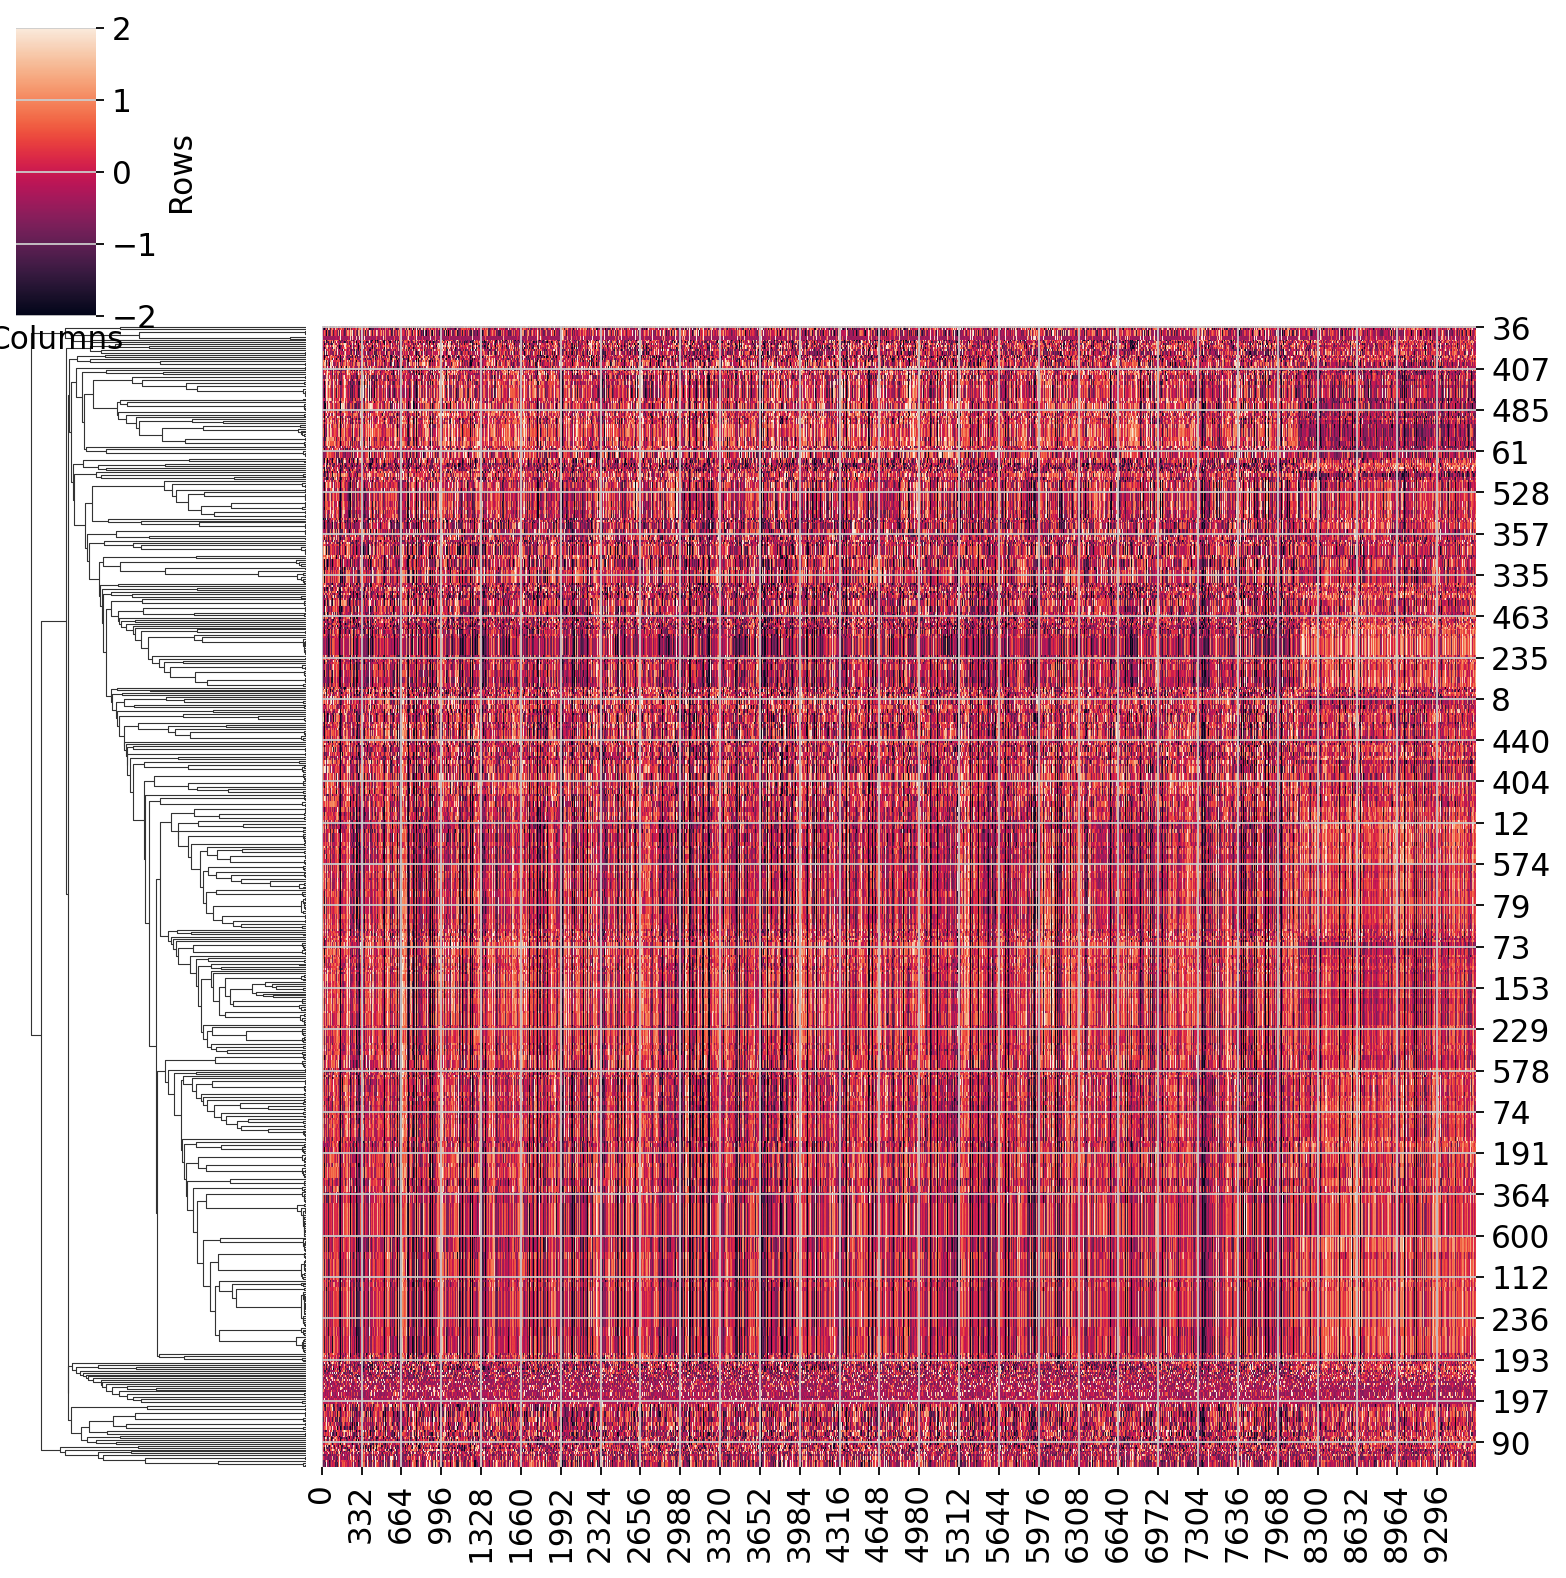

In [57]:

LL_net.cell_type_specific_cis_reg(GRNdir,adata_RNA,adata_ATAC,genome,celltype,outdir,method)

LL_net.cell_type_specific_trans_reg(GRNdir,adata_RNA,celltype,outdir)

network = 'general'

network = 'cell population'

network = 'IDHm' # CD56 (bright) NK cells is the name of one cell type

Datadir='/home/qyyuan/data/TF_TG_software/code/'# This directory should be the same as Datadir defined in the above 'Download the general gene regulatory network' section
GRNdir=Datadir+'data_bulk/'
genome='hg38'
outdir='/home/qyyuan/project/Nature-Protocol/cancer/result/' 
from LingerGRN.TF_activity import *
# outdir='/zfs/durenlab/palmetto/Kaya/SC_NET/code/github/combine/LINGER/examples/output/' #output dir
import anndata
adata_RNA=anndata.read_h5ad('data/adata_RNA.h5ad')
TF_activity=regulon(outdir,adata_RNA,GRNdir,network,genome)

save=True
heatmap_cluster(TF_activity,adata_RNA,save,outdir)

